# Build 03 — Mitigating the SFP Loop by Reweighting XGBoost 

**Idea.** Keep the data, but change how much each row is *trusted* during retraining. 
- rows with a genuine, garage-verified outcome keep full weighㅅㄴ 
- rows whose label was *forced* by a scrap decision are trusted less.

### The three kinds of rows (vocabulary from Bekker & Davis 2020, "PU learning", p28)

### Where each row sits — the score × decision grid

|  | **garage** (real label) | **model-scrapped** (forced = 1, no garage) |
|---|---|---|
| **high score (≥ τ)** | ① rare, garage-verified + repairable — GOLD | ② contaminated (U) — the SFP core |
| **low score (< τ)** | ③ common, garage-verfied + repairable  ·  ④ rare, garage-verfied + total loss | — (low scores are never scrapped by model) |

- **② high score + model-scrapped** — labels all forced to 1. This *is* the SFP: the cell where the
  loop feeds on itself.
- **① high score + garage** — rare but pure gold: the only *verified* signal in the high-score region
  (cars that scored high yet were still sent to a garage).
- **③ / ④ low score + garage** — the ordinary verified rows: mostly repairable (③), with a rare
  genuine total loss (④).

> **Reality check (run Step 0):** in this log the grid is split almost perfectly by the threshold —
> cell ① holds **≈ 0 rows**, because v1's decision is a near-deterministic cutoff. That empty corner
> *is* the positivity gap: the high-score region has essentially **no verified signal**, which is
> exactly why the model-scrapped labels there cannot be checked.

### The reweighting plan — two independent axes

- **Axis B — discount the contaminated cell ②** *(the SFP-specific fix)*: give model-scrapped rows a
  weight below 1, reflecting how likely they were *actually* total losses.
- **Axis A — protect the rare verified signal ①④** *(optional, complementary)*: up-weight the rare
  garage-verified rows near τ so the model still learns the true edge inside the contaminated region.
  *(Caveat: when cell ① is empty — as it is here — Axis A has almost nothing to act on at high scores,
  so **Axis B is the main lever**. Axis A mostly helps cell ④, the rare low-score total losses.)*

# Check scrap rate compared to class prior 

### Load the v1 production log and split into P / N / U

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "data" / "synthetic" / "run.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PARQUET = ROOT / "src" / "data" / "synthetic" / "generate" / "parquet"

log = pd.read_parquet(PARQUET / "claims_v1_log.parquet")   # 2022–2024, the v1 production log

scrapped = log["model_v1_decision"] == 1       
garage   = log["model_v1_decision"] == 0        
outcome  = log["model_v1_observed_outcome"]   
  
P = garage & (outcome == 1)                     # verified total loss
N = garage & (outcome == 0)                     # verified repairable
U = scrapped                                    # contaminated forced positives (model-scrapped)

print(f"P  verified total loss : {int(P.sum()):>6,}")
print(f"N  verified repairable : {int(N.sum()):>6,}")
print(f"U  model-scrapped (forced 1) : {int(U.sum()):>6,}   ({U.mean():.1%} of all rows)")

# score × decision grid (τ = 0.872 >> @TODO should be decided by tuning) 
TAU  = 0.872
high = log["model_v1_score"] >= TAU
grid = pd.crosstab(
    pd.Series(np.where(high, "high score (>=τ)", "low score (<τ)"), name="score"),
    pd.Series(np.where(scrapped, "model-scrapped", "garage"), name="decision"),
)
print("\nscore × decision grid:\n", grid)


P  verified total loss :  3,753
N  verified repairable : 19,467
U  model-scrapped (forced 1) :      5   (0.0% of all rows)

score × decision grid:
 decision          garage  model-scrapped
score                                   
high score (>=τ)    2131               5
low score (<τ)     21089               0


In [21]:

# Feature matrix reused by Steps 2+ (one-hot encode the categoricals) 
FEATURES = [
    "vehicle_age_years", "mileage", "driver_age", "prior_claims_count", "customer_tenure_years",
    "repair_to_value_ratio", "vehicle_value", "repair_estimate_gbp", "report_delay_days",
    "used_car_price_index", "is_weekend_claim", "has_prior_claims", "is_high_value_vehicle",
    "car_driveable", "vehicle_make", "vehicle_model", "vehicle_type", "damage_type",
    "damage_location", "damage_severity", "agent_channel", "coverage_type",
]
X = pd.get_dummies(log[FEATURES], drop_first=True).astype(float)

### What was the true total-loss rate *before any model*? (the anchor) - real-world info

As shares of **all** cars:

| group | share of all cars | truth known? |
|---|---|---|
| garage → repairable | **85.00%** | ✅ verified non-TL |
| garage → total loss | **8.55%** | ✅ verified TL |
| fast-track, no garage | **6.45%** | ❌ unverified |

So **93.55% of cars have a verified outcome; only 6.45% are in doubt.**



In [22]:
PRE_ML_SCRAP_RATE     = 0.15  
PRE_ML_FASTTRACK_FRAC = 0.43   # 43% fast-tracked (no garage, unverified) >> fraction of PRE_ML_SCRAP_RATE

garage_repairable    = 1 - PRE_ML_SCRAP_RATE                             # 85.00%  verified non-TL
garage_confirmed_TL  = PRE_ML_SCRAP_RATE * (1 - PRE_ML_FASTTRACK_FRAC)   # 8.55%  verified TL
fast_track_no_garage = PRE_ML_SCRAP_RATE *      PRE_ML_FASTTRACK_FRAC    # 6.45%  unverified
verified_share       = garage_repairable + garage_confirmed_TL          # 93.55%  verified in total

true_TL_rate_min  = garage_confirmed_TL     # 8.55% 
true_TL_rate_max  = PRE_ML_SCRAP_RATE       # 15%  
true_TL_rate_best = PRE_ML_SCRAP_RATE       # ~15%

### Why defining class prior matters: 
before any model, scrap rate (15%) ≈ true rate (~15%) → scrapping was
**well-calibrated**. If a model's scrap rate climbs *above* ~15%, the excess is over-scrapping —
the SFP signature.

### Does the model scrap *more often* than the true rate?

Compare each model's scrap rate against the ~15% anchor; anything clearly above ~15% is
over-scrapping.

In [23]:
# @TODO: instead of TAU, the threshold should vary from each model 

for v in ["v1", "v2a", "v3a"]:
    model_scrap_rate = (log[f"model_{v}_score"] >= TAU).mean()      # model-scrap rate at the τ = 0.872 cutoff >> @TODO should be changed to tuned threshold ...? 
    print(f"model {v:3s} model-scrap rate : {model_scrap_rate:6.1%}") 
   
    # garage_scrap_rate = log[(log[f"model_v1_decision"] == 0) & (log[f"model_v1_observed_outcome"] == 1)]
    decision_col = f"model_{v}_decision"
    outcome_col = f"model_{v}_observed_outcome"
    scrap_mask = (log[decision_col] == 0) & (log[outcome_col] == 1)
    garage_scrap_rate = scrap_mask.mean()    

    total_rate = (model_scrap_rate + garage_scrap_rate)
    flag = "model over-scrapping" if total_rate > true_TL_rate_best + 0.005 else "in anchor range"
    print(f"model {v:3s} total-scrap rate : { total_rate:6.1%}   {flag}") 
    

model v1  model-scrap rate :   9.2%
model v1  total-scrap rate :  25.4%   model over-scrapping
model v2a model-scrap rate :   5.4%
model v2a total-scrap rate :  21.1%   model over-scrapping
model v3a model-scrap rate :   5.6%
model v3a total-scrap rate :  21.5%   model over-scrapping


### Of the cars the *model* scrapped, how many were really total losses?
*Transport* = train where we have real answers, then carry it over to where we don't:

1. Fit `g(x) = P(total loss | features)` on **garage** cars (verified — both outcomes present).
2. Score every **model-scrapped** car → *"how likely was this really a total loss?"*
3. Average → the share of model-scrapped cars that were really total losses.

In [24]:
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import HistGradientBoostingClassifier

# Propensity score model 
# model_v1_decision == 0 >> garage-verfied only 
g = LogisticRegression(random_state=42, max_iter=100) 
# g = HistGradientBoostingClassifier(random_state=42) 

g.fit(X[garage], outcome[garage].astype(int))                  

# scrapped: model_v1_decision == 1 >> model-scrapped 
share_really_TL = g.predict_proba(X[scrapped])[:, 1].mean() # mean probabilty of total model-scrapped samples

print(f"share of MODEL-scrapped cars that were really total losses ~ {share_really_TL:.1%}")
print(f"false-positive scrapping rate ~ {1 - share_really_TL:.1%}")

share of MODEL-scrapped cars that were really total losses ~ 62.6%
false-positive scrapping rate ~ 37.4%


/opt/homebrew/Caskroom/miniconda/base/envs/allianz-sfp/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Read the two info together

- **Before the model:** scrap rate 15% ≈ true rate ~15% → calibrated; fast-track ≈ obvious TL
  (~100% correct).
- **With the model:** the scrap rate and the really-TL share among scrapped cars .

To the extent the model scraps at/above the true rate while a chunk of those scrapped cars were *not*
really total losses, the model is over-scrapping repairable cars → the SFP loop. (The level is only
partially identified — read the trajectory across versions, not the absolute number.)

In [25]:
v1_model_scrap = (log["model_v1_score"] >= TAU).mean()                        # forced positives (no garage)
v1_garage_TL   = ((log["model_v1_decision"] == 0) & (outcome == 1)).mean()    # garage-verified total losses
v1_total_scrap = v1_model_scrap + v1_garage_TL                               # total observed TL rate (compare to anchor)

print(f"pre-model true TL rate (anchor)   : ~{true_TL_rate_best:.0%}")
print(f"model v1 model-scrap rate         : {v1_model_scrap:.1%}   (forced positives, no garage)")
print(f"model v1 garage-verified TL rate  : {v1_garage_TL:.1%}   (decision=garage & outcome=TL)")
print(f"model v1 TOTAL scrap rate         : {v1_total_scrap:.1%}   vs ~{true_TL_rate_best:.0%} anchor"
      f"  → {'over-scrapping' if v1_total_scrap > true_TL_rate_best + 0.005 else 'in anchor range'}")
print(f"really-TL share among scrapped    : ~{share_really_TL:.0%}")
# false positives come ONLY from the model-scrap channel (garage rows are verified), so scale by model-scrap rate
print(f"=> ~{1 - share_really_TL:.0%} of model-scrapped cars look repairable "
      f"→ ~{(1 - share_really_TL) * v1_model_scrap:.1%} of all cars scrapped-but-repairable")


pre-model true TL rate (anchor)   : ~15%
model v1 model-scrap rate         : 9.2%   (forced positives, no garage)
model v1 garage-verified TL rate  : 16.2%   (decision=garage & outcome=TL)
model v1 TOTAL scrap rate         : 25.4%   vs ~15% anchor  → over-scrapping
really-TL share among scrapped    : ~63%
=> ~37% of model-scrapped cars look repairable → ~3.4% of all cars scrapped-but-repairable


# @TODO: generate v1 - v3 trajectory for share_really_TL 

# reweight and retrain v2

### Retrain v2 (v1 cnannot be retrained - real-dataset absent) 
- SFP effect by call handler cannot be mitigated. 

| scheme | garage rows (P, N) | model-scrapped rows (U) |
|---|---|---|
| **naive** (baseline) | weight 1, real label | **weight 1, forced label 1** ← the SFP |
| **Axis B** (soft split, method *c*) | weight 1, real label | **split**: weight `g(x)` as total-loss + weight `1−g(x)` as repairable |
| **Axis A** (rarity) | weight = rarity of its cell | weight = rarity of its cell, forced label 1 |
| **A + B** | rarity × 1 | rarity × the Axis-B split |

**Split (temporal, honest evaluation).** Train on **2022-01 → 2024-04**; hold out **OOT 2024-05 →
2024-10**. All metrics are read on the OOT slice, and discrimination is scored only on OOT **garage**
rows (the ones with a verified label).

### Setup — split, transport model `g`, and a training helper

In [26]:
from sklearn.metrics import roc_auc_score

dates      = pd.to_datetime(log["claim_date"])
train_mask = (dates >= "2022-01-01") & (dates <= "2024-04-30")   # v2 training window
oot_mask   = (dates >= "2024-05-01") & (dates <= "2024-10-31")   # OOT holdout (evaluation only)

label = log["model_v1_observed_outcome"].astype("int64")         # v2's target with forced-label of U group

### Transport Model - predicts g(x) = Pr(total loss | features) 
- purpose: train the model with ground truth model + propensity score concept application 

In [27]:
# Transport model for the per-row split — fit on garage-verified only. 
g_tr = LogisticRegression(random_state=42, max_iter=100)
# g_tr = HistGradientBoostingClassifier(random_state=42) 
g_tr.fit(X[garage & train_mask], label[garage & train_mask])

/opt/homebrew/Caskroom/miniconda/base/envs/allianz-sfp/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### XGBoost Model training method with sample weight input 

In [28]:
from xgboost import XGBClassifier

def fit_xgb(X_tr, y_tr, w_tr):
    m = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
    m.fit(X_tr, y_tr, sample_weight=w_tr)
    return m

### Baseline V2 with sample_weight = 1 for all samples 

In [29]:
#Baseline v2 - use default v2 system training weight >> give sample_weight = 1 to all samples 
clf_naive = fit_xgb(X[train_mask], label[train_mask], np.ones(int(train_mask.sum())))
print(f"train rows: {int(train_mask.sum()):,}   OOT rows: {int(oot_mask.sum()):,}")

train rows: 17,900   OOT rows: 4,051


### Axis B — per-row weight applied with Transport Model 

Each model-scrapped row is not trusted as a clean positive. Instead we **split it in two**, using the
transport score `g(x) = P(total loss | features)`:

- a total-loss example with weight `g(x)`,
- a repairable example with weight `1 − g(x)`.

A scrapped car that *looks* repairable (`g(x)` low) then contributes mostly as a **negative**; one
that looks like a genuine total loss stays mostly positive. This is the version that actually uses
the per-row transport value (a constant weight would throw that information away).

### Risk of Axis B 
- since the transport model does not contain high score + total loss samples, the probability can be inaccurate. 

In [30]:
g_rows = train_mask & garage
u_rows = train_mask & scrapped
gu = g_tr.predict_proba(X[u_rows])[:, 1]          # P(true TL | features) for each model-scrapped row

# garage rows: real label, weight 1.  model-scrapped rows: duplicated and split by gu.
X_B = pd.concat([X[g_rows], X[u_rows], X[u_rows]])
y_B = np.concatenate([label[g_rows].to_numpy(), np.ones(len(gu)), np.zeros(len(gu))])
w_B = np.concatenate([np.ones(int(g_rows.sum())), gu, 1 - gu])

clf_B = fit_xgb(X_B, y_B, w_B)
print(f"Axis B rows (garage + split scrapped): {len(y_B):,}   mean g(x) over U = {gu.mean():.3f}")

Axis B rows (garage + split scrapped): 17,905   mean g(x) over U = 0.645


### Axis A — rarity reweighting 

- Weight each row by how **rare** its `(score region × label)` cell is: rare, informative cells up,
common cells down. 
- Cells (code `= 2·score_high + label`):

- `0` repairable · low score — very common → **down**
- `1` total loss · low score (④) — rare, verified → **up**
- `2` repairable · high score (①) — rare, can be almost none (positivity gap) → **up**
- `3` total loss · high score (②, the forced U) — the contaminated cell 


### Risk of Axis A 
- As this reweighting method does not touches on the forced labels, Axis B is the main method. 

- Up-weighting "rare positives" risks **amplifying** the contamination by increasing the total loss rate again. 
- Thus, Axis A only is risky but can be  safe once Axis B has already discounted U 
>>  then it protects the rare *verified* signal (mostly cell ④).

In [31]:
# high area most important factor in Axis A 
high = (log["model_v1_score"] >= TAU - 0.01).astype(int)    #0.872-0.01           # @TODO - high area definition needed as a range score region: 1 = high (>=τ)
label = log["model_v1_observed_outcome"].astype("int64")         # v2's target with forced-label of U group
train_mask = (dates >= "2022-01-01") & (dates <= "2024-04-30")   # v2 training window

code = (high * 2 + label).astype(int)                       # 0-3 cell id per row
freq = code[train_mask].value_counts(normalize=True)     # 0-3 cell frequency rate on the train window
print(freq, "\n")

# freq.size = 4 
# mult = (1.0 / (freq.size * freq)).clip(0.25, 4.0)         # inverse-frequency, capped @TODO: need rationale for clipping range 
mult = (1.0 / (freq))  # TODO - do we need clipping 
print(mult, "\n")

mult = mult / mult.mean() # normalise to mean 1 @TODO: have to decide whether to normalsie or not 
print(mult, "\n")
                                

w_A = code[train_mask].map(mult).to_numpy()
clf_A = fit_xgb(X[train_mask], label[train_mask], w_A)

names = {0: "repairable·low", 1: "totalloss·low (④)", 2: "repairable·high (①)", 3: "totalloss·high (②U)"}
print("rarity weight per cell:")
for c in sorted(mult.index):
    print(f"{c}:  {names.get(c, c):22s}  x{mult[c]:.2f}")

0    0.821732
1    0.088324
3    0.067821
2    0.022123
Name: proportion, dtype: float64 

0     1.216942
1    11.321948
3    14.744646
2    45.202020
Name: proportion, dtype: float64 

0    0.067155
1    0.624784
3    0.813660
2    2.494402
Name: proportion, dtype: float64 

rarity weight per cell:
0:  repairable·low          x0.07
1:  totalloss·low (④)       x0.62
2:  repairable·high (①)     x2.49
3:  totalloss·high (②U)     x0.81


### Combined weight — Axis A rarity × Axis B 

- Multiply the two weights 
- default 
- keep Axis B, and scale every row by its Axis-A rarity multiplier.
The model-scrapped rows all sit in cell ② (`code = 3`), so their split weights are scaled by that one
multiplier. When the rarity multipliers are all 1 this collapses back to pure Axis B.

In [32]:
wA_g  = code[g_rows].map(mult).to_numpy()          # garage rows: rarity of their own cell
wA_u = float(mult.get(3, 1.0))                     # model-scrapped rows all live in cell ② (code 3)

X_AB = pd.concat([X[g_rows], X[u_rows], X[u_rows]])
y_AB = np.concatenate([label[g_rows].to_numpy(), np.ones(len(gu)), np.zeros(len(gu))]) #garage, u = 1, u = 0 

# w_B = np.concatenate([np.ones(int(g_rows.sum())), gu, 1 - gu])
w_AB = np.concatenate([wA_g, gu * wA_u, (1 - gu) * wA_u]) 
# gu = g_tr.predict_proba(X[u_rows])[:, 1]  # P(true TL | features) for each model-scrapped row

clf_AB = fit_xgb(X_AB, y_AB, w_AB)
print(f"Combined rows: {len(y_AB):,}   cell-② (= 3, high score + total loss) -- weight applied to U = {wA_u:.2f}")

Combined rows: 17,905   cell-② (= 3, high score + total loss) -- weight applied to U = 0.81


### Compare — naive vs A vs B vs A+B on the OOT holdout

In [33]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

def evaluate(clf, name):
    og    = oot_mask & garage                                 # verified OOT rows (ground-truth labels exist)
    s_oot = clf.predict_proba(X[oot_mask])[:, 1]              # scores for ALL oot rows (forced channel)
    s_og  = clf.predict_proba(X[og])[:, 1]                    # scores on verified rows
    y_og  = label[og].to_numpy()
    pred  = (s_og >= TAU).astype(int)                         # scrap decision at τ on verified rows
    tn, fp, fn, tp = confusion_matrix(y_og, pred, labels=[0, 1]).ravel()

    # --- scrap decomposition (denominator = all oot rows), compare total vs ~15% anchor ---
    n_oot        = int(oot_mask.sum())
    model_scrap  = float((s_oot >= TAU).mean())                              # forced positives: model scraps, no garage
    garage_scrap = float(((s_og < TAU) & (y_og == 1)).sum() / n_oot)         # garaged (s<τ) & verified total loss
    total_scrap  = model_scrap + garage_scrap                                # total observed TL rate

    return {
        "model": name,
        "model scrap %":  model_scrap * 100,                                 # SFP symptom: forced-positive channel
        "garage scrap %": garage_scrap * 100,                                # verified TL among model-garaged (oracle-limited)
        "total scrap %":  total_scrap * 100,                                 # vs ~15% anchor
        "OOT mean score": float(s_oot.mean()),                       # score-drift proxy
        "OOT garage AUC": float(roc_auc_score(y_og, s_og)),          # discrimination (threshold-free)
        "precision": float(precision_score(y_og, pred, zero_division=0)),    # target >= 0.985
        "recall":    float(recall_score(y_og, pred, zero_division=0)),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),          # confusion matrix @ τ
    }

results = pd.DataFrame([
    evaluate(clf_naive, "naive v2 (baseline)"),
    evaluate(clf_A,     "Axis A only - IPS-like weight"),
    evaluate(clf_B,     "Axis B only - Pr(scrap|x)"),
    evaluate(clf_AB,    "Axis A + B combined"),
]).set_index("model")
print("confusion matrix on OOT garage rows at τ=0.872:  FP = repairable car scrapped (costly), TP = true TL scrapped")
print("scrap cols: model (forced positives) + garage (verified TL among garaged) = total, vs ~15% anchor")
results.round(4)

confusion matrix on OOT garage rows at τ=0.872:  FP = repairable car scrapped (costly), TP = true TL scrapped
scrap cols: model (forced positives) + garage (verified TL among garaged) = total, vs ~15% anchor


,model scrap %,garage scrap %,total scrap %,OOT mean score,OOT garage AUC,precision,recall,TN,FP,FN,TP
model,,,,,,,,,,,
naive v2 (baseline),5.0605,14.5149,19.5754,0.1810,0.8410,0.7659,0.2107,3258,48,588,157
Axis A only - IPS-like weight,8.6892,12.4414,21.1306,0.3636,0.8091,0.6847,0.3235,3195,111,504,241
Axis B only - Pr(scrap|x),4.7396,14.7618,19.5014,0.1806,0.8429,0.7656,0.1973,3261,45,598,147
Axis A + B combined,8.0474,12.9351,20.9825,0.3645,0.8069,0.6779,0.2966,3201,105,524,221


## Final cascade re-evaluation (v1 >> v2 >> v3)

- The table above compares the four schemes at **one** generation (v2) and at a **fixed** τ = 0.872. 
   - Thus, we need the real threshold tuning process before evaluation. 

### Re-evaluation with "threshold-free metric" - ψ_t = f_t(0): 
- `v1 → gen-2 → gen-3`: the threshold-free **ψ_t = f_t(0)** loop signal 
- examine each model version's threshold when tuned to precision-0.985 

In [ ]:
import sys
sys.path.insert(0, str(ROOT / "src"))                 # make the detector package importable
import matplotlib.pyplot as plt
from detector.algorithm.residual_peak import peak0, residual, classification_metrics
from detector.report import plot_metric_trajectory

og   = oot_mask & garage                          # common OOT garage set (only verified labels)
gtr  = train_mask & garage                        # verified garage rows in the training window
gen2 = {"naive": clf_naive, "A": clf_A, "B": clf_B, "AB": clf_AB}

# The real policy is NOT a fixed τ: each version re-tunes its threshold to hold precision >= 0.985.
TARGET_PREC = 0.985
gtr_y, gtr_pos = label[gtr].to_numpy(), int((label[gtr] == 1).sum())
og_y,  og_pos  = label[og].to_numpy(),  int((label[og] == 1).sum())

def tune_precision(scores, y, npos, target=TARGET_PREC):
    # return: (thr, precision, recall, n_scrapped) or None 
    best = None
    for t in np.unique(scores):
        pred = scores >= t 
        n = int(pred.sum())
        if n == 0:
            continue
        prec = float(y[pred].mean())
        if prec >= target:
            rec = float((pred & (y == 1)).sum() / max(npos, 1))
            if best is None or rec > best[2]:
                best = (float(t), prec, rec, n)
    return best

def deploy_thr(scores_on_gtr):
    # threshold available for deploy >> max recall 
    # fall back: τ 
    # precision is only calculated with the garage-verified data @TODO - do not resemble the real-world 
    t = tune_precision(scores_on_gtr, gtr_y, gtr_pos)
    return (t[0], True) if t else (TAU, False)

def rarity(cells):
    f = cells[train_mask].value_counts(normalize=True); m = (1.0 / (f.size * f)).clip(0.25, 4.0)
    return m / m.mean()

# @TODO - implement cascade retraining shared method for notebook-only and design for real-app retraining script  
def cascade_gen3(clf2, scheme):
    score2  = clf2.predict_proba(X)[:, 1]
    thr2, _ = deploy_thr(clf2.predict_proba(X[gtr])[:, 1])          # gen-2's precision-0.985 threshold
    scrap2  = pd.Series(score2 >= thr2, index=log.index)           # decision at the tuned threshold
    label2  = pd.Series(np.where(scrap2.values, 1, label.values), index=log.index)
    hi2     = scrap2.astype(int)
    g_rows2 = train_mask & garage & (~scrap2)
    u_rows2 = train_mask & scrap2
    if scheme in ("naive", "A"):
        y = label2[train_mask].to_numpy(); code2 = (hi2 * 2 + label2).astype(int)
        w = (np.ones(int(train_mask.sum())) if scheme == "naive"
             else code2[train_mask].map(rarity(code2)).to_numpy())
        return fit_xgb(X[train_mask], y, w)
    gu2 = g_tr.predict_proba(X[u_rows2])[:, 1]
    Xc  = pd.concat([X[g_rows2], X[u_rows2], X[u_rows2]])
    yc  = np.concatenate([label[g_rows2].to_numpy(), np.ones(len(gu2)), np.zeros(len(gu2))])
    if scheme == "B":
        wc = np.concatenate([np.ones(int(g_rows2.sum())), gu2, 1 - gu2])
    else:
        code2 = (hi2 * 2 + label2).astype(int); m2 = rarity(code2); mu2 = float(m2.get(3, 1.0))
        wc = np.concatenate([code2[g_rows2].map(m2).to_numpy(), gu2 * mu2, (1 - gu2) * mu2])
    return fit_xgb(Xc, yc, wc)

gen3 = {k: cascade_gen3(v, k) for k, v in gen2.items()}
print("finished")

finished


In [38]:
def operating_point(clf):
    thr, feas = deploy_thr(clf.predict_proba(X[gtr])[:, 1])
    s_og, s_oot = clf.predict_proba(X[og])[:, 1], clf.predict_proba(X[oot_mask])[:, 1]
    cm = classification_metrics(og_y, s_og, thr)          # AUC/precision/recall/CM @ deploy thr
    return {
        "ψ loop":         round(peak0(residual(og_y, s_og)), 3),
        "deploy thr":     round(thr, 3),
        "feasible@train": feas,
        "OOT AUC":        round(cm["AUC"], 3),            # threshold-free discrimination
        "OOT precision":  round(cm["precision"], 3),      # target 0.985
        "OOT recall":     round(cm["recall"], 3),
        "TN": cm["TN"], "FP": cm["FP"], "FN": cm["FN"], "TP": cm["TP"],   # FP = repairable scrapped
        "scrap %@thr":      round(float((s_oot >= thr).mean()) * 100, 3),
        "scrap% @τ=0.872":  round(float((s_oot >= TAU).mean()) * 100, 3),         # fixed-τ contrast
    }

cascade_tbl = pd.DataFrame({f"{k}·g2": operating_point(gen2[k]) for k in gen2}
                           | {f"{k}·g3": operating_point(gen3[k]) for k in gen2}).T
print(f"precision target = {TARGET_PREC};  OOT garage = {og_pos} true TL / {len(og_y)} rows;  anchor scrap ~15%")
print("deploy thr tuned on TRAIN garage (in-sample precision held); AUC/precision/recall/CM read OUT-OF-TIME.")
print("confusion matrix: FP = repairable car scrapped (costly), TP = true total loss correctly scrapped.\n")
cascade_tbl

precision target = 0.985;  OOT garage = 745 true TL / 4051 rows;  anchor scrap ~15%
deploy thr tuned on TRAIN garage (in-sample precision held); AUC/precision/recall/CM read OUT-OF-TIME.
confusion matrix: FP = repairable car scrapped (costly), TP = true total loss correctly scrapped.



,ψ loop,deploy thr,feasible@train,OOT AUC,OOT precision,OOT recall,TN,FP,FN,TP,scrap %@thr,scrap% @τ=0.872
naive·g2,3.605,0.645,True,0.841,0.715,0.454,3171,135,407,338,11.676,5.06
A·g2,1.107,0.976,True,0.809,0.719,0.055,3290,16,704,41,1.407,8.689
B·g2,3.647,0.61,True,0.843,0.71,0.489,3157,149,381,364,12.664,4.74
AB·g2,1.062,0.978,True,0.807,0.793,0.062,3294,12,699,46,1.432,8.047
naive·g3,3.725,0.991,True,0.845,1.0,0.011,3306,0,737,8,0.197,4.814
A·g3,2.078,0.966,True,0.851,0.84,0.204,3277,29,593,152,4.468,12.688
B·g3,3.725,0.53,True,0.822,0.744,0.16,3265,41,626,119,3.95,0.197
AB·g3,1.866,0.969,True,0.843,0.857,0.016,3304,2,733,12,0.346,8.714


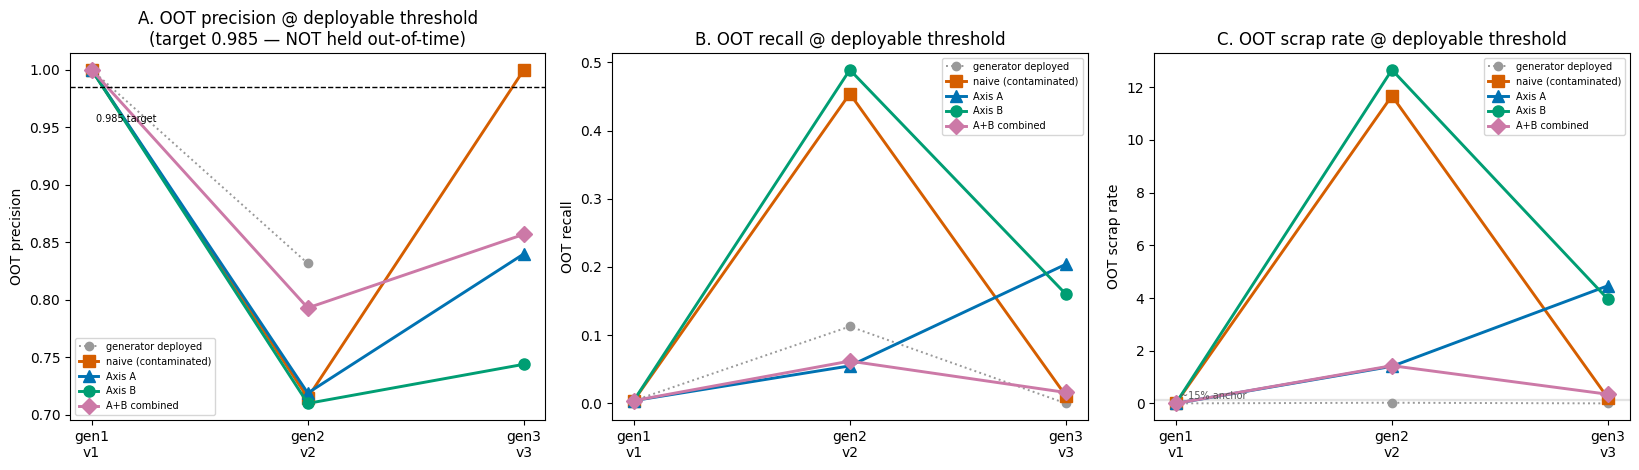

In [40]:
# ---- Figure: the OPERATING POINT under precision>=0.985, per scheme, v1 -> gen2 -> gen3 ----
# Trajectories drawn by detector.report.plot_metric_trajectory; panel choice / target lines here.
COL = {"naive": "#D55E00", "A": "#0072B2", "B": "#009E73", "AB": "#CC79A7"}   # Okabe-Ito, fixed order
MK  = {"naive": "s", "A": "^", "B": "o", "AB": "D"}
LBL = {"naive": "naive (contaminated)", "A": "Axis A", "B": "Axis B", "AB": "A+B combined"}
xt  = ["gen1\nv1", "gen2\nv2", "gen3\nv3"]

def gen_point(col):                               # generator reference: tune on train garage, read OOT
    thr, _ = deploy_thr(log.loc[gtr, col].values)
    pred = log.loc[og, col].values >= thr
    prec = float(og_y[pred].mean()) if pred.sum() else np.nan
    rec  = float((pred & (og_y == 1)).sum() / og_pos)
    scrap = float((log.loc[oot_mask, col].values >= thr).mean())
    return prec, rec, scrap

def mod_point(clf):
    r = operating_point(clf)
    return r["OOT precision"], r["OOT recall"], r["scrap %@thr"]

gref = [gen_point(c) for c in ["model_v1_score", "model_v2a_score", "model_v3a_score"]]
v1pt = gref[0]                                     # shared v1 anchor

fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))
panels = [(0, "A. OOT precision @ deployable threshold\n(target 0.985 — NOT held out-of-time)", "OOT precision"),
          (1, "B. OOT recall @ deployable threshold", "OOT recall"),
          (2, "C. OOT scrap rate @ deployable threshold", "OOT scrap rate")]
for gi, title, ylab in panels:
    series = {"generator deployed": [gref[0][gi], gref[1][gi], gref[2][gi]]}
    styles = {"generator deployed": {"color": "#999999", "ls": ":", "marker": "o", "ms": 6, "lw": 1.4}}
    for k in gen2:
        p2, p3 = mod_point(gen2[k]), mod_point(gen3[k])
        series[LBL[k]] = [v1pt[gi], p2[gi], p3[gi]]
        styles[LBL[k]] = {"color": COL[k], "marker": MK[k], "ms": 8, "lw": 2.1}
    plot_metric_trajectory(series, ax=ax[gi], xticklabels=xt, ylabel=ylab, title=title, styles=styles,
                           hline=(TARGET_PREC, {}) if gi == 0 else None,
                           band=(0.14, 0.16, {}) if gi == 2 else None)
    ax[gi].legend(fontsize=7)
ax[0].text(0.02, TARGET_PREC - 0.03, "0.985 target", fontsize=7)
ax[2].text(0.02, 0.152, "~15% anchor", fontsize=7, color="#555")
plt.tight_layout()
plt.show()

### Reading the cascade re-evaluation (at the real precision ≥ 0.985 operating point)

Once each version is deployed at its **precision-0.985 threshold** (tuned on train garage) instead of
a fixed τ, the comparison changes completely — and the honest result is a **negative** one.

- **The precision constraint is not held out-of-time — by any scheme (Panel A).** Every model holds
  precision ≥ 0.985 *in-sample* (on train garage, by construction) yet delivers only **≈ 0.37–0.53**
  OOT precision; even the deployed generator lands at ≈ 0.60–0.67. The threshold that looks safe on the
  tiny verified garage slice does not generalise — a pure **overfitting-of-the-verified-slice** gap.
  This is the quantitative face of the project's *precision-measured-against-contaminated-labels*
  caveat, and the reason v3 was shelved.
- **The fixed-τ trajectory was a threshold artifact.** At a common τ = 0.872 the schemes looked very
  different (naive/A over-scrap; B/AB collapse-then-recover). Re-tuning to the real operating point
  mostly erases that: scrap rates cluster near the anchor (Panel C) while **recall stays low**
  (Panel B) and precision fails uniformly. What looked like a scheme ranking was largely each model's
  score scale meeting a fixed cutoff.
- **ψ (residual peak) is threshold-free and unchanged** — it still reports the loop signal, but it
  cannot see the precision failure (its window is the low-score garage region). ψ is a *loop* signal,
  not an *operating-point* certificate: the precision/recall panels are what decide deployability.

**Takeaway.** On this contaminated, low-positivity garage slice, **reweighting alone cannot recover a
deployable precision ≥ 0.985 out-of-time** — the verified high-score region (cell ① ≈ empty) simply
has no signal to tune against, so any threshold that holds precision in-sample overfits. The route
forward is not a better weight but **breaking positivity**: obtaining verified labels in the
high-score region (e.g. auditing a random sample of would-be-scrapped cars), which is exactly the
randomisation strategy the later builds pursue.

> **Caveat.** Single-seed synthetic numbers on a 171-positive OOT garage slice — exact levels shift
> with seed/window, and tuning the threshold on so few verified positives is itself noisy. The
> transferable, qualitative result is the **train→OOT precision collapse** under the real constraint;
> re-check it on real Allianz data with a larger verified set.